In [2]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore
import warnings
import spacy # type: ignore
from collections import Counter

warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'D:\End-to-end-ML\Customer-Risk-Escalation-Engine\data\raw_data\support_tkts.csv')
df

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,TCKT_099996,2023-05-16T06:23:50,CUST_06828,education,in_app,analytics_dashboard,billing_problem,high,resolved,standard,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,7.97,0,neutral,0,0,desktop_app,EU
99996,TCKT_099997,2025-03-10T04:46:24,CUST_06621,education,in_app,billing,bug,low,resolved,standard,I am seeing an error message when I click on b...,Thanks for reporting this bug. We will look in...,Patched the bug and deployed a fix to production.,16.48,0,negative,2,0,api_client,MEA
99997,TCKT_099998,2025-11-07T19:33:01,CUST_03719,non_profit,chat,billing,bug,low,resolved,standard,I am seeing an error message when I click on b...,Thanks for reporting this bug. We will look in...,Patched the bug and deployed a fix to production.,56.99,0,very_positive,5,0,web,LATAM
99998,TCKT_099999,2022-06-20T22:29:10,CUST_02290,small_business,email,analytics_dashboard,account_access,low,open,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,neutral,0,1,api_client,NaN


###  Basic Understanding

In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 3 rows:\n", df.head(3))

Shape: (100000, 20)

Columns: ['ticket_id', 'created_at', 'customer_id', 'customer_segment', 'channel', 'product_area', 'issue_type', 'priority', 'status', 'sla_plan', 'initial_message', 'agent_first_reply', 'resolution_summary', 'resolution_time_hours', 'reopened', 'customer_sentiment', 'csat_score', 'has_attachment', 'platform', 'region']

Data Types:
 ticket_id                 object
created_at                object
customer_id               object
customer_segment          object
channel                   object
product_area              object
issue_type                object
priority                  object
status                    object
sla_plan                  object
initial_message           object
agent_first_reply         object
resolution_summary        object
resolution_time_hours    float64
reopened                   int64
customer_sentiment        object
csat_score                 int64
has_attachment             int64
platform                  object
region          

In [5]:
print("customer_sentiment values:")
print(df['customer_sentiment'].value_counts())

print("\ncsat_score values:")
print(df['csat_score'].value_counts())

print("\nstatus values:")
print(df['status'].value_counts())

print("\nreopened values:")
print(df['reopened'].value_counts())

print("\nresolution_time_hours stats:")
print(df['resolution_time_hours'].describe())

customer_sentiment values:
customer_sentiment
neutral          32634
negative         26015
very_negative    16437
positive         16242
very_positive     8672
Name: count, dtype: int64

csat_score values:
csat_score
0    29941
3    20453
4    17321
2    14871
5    11599
1     5815
Name: count, dtype: int64

status values:
status
resolved            50131
in_progress         19783
on_hold             10165
closed_no_action     9982
open                 9939
Name: count, dtype: int64

reopened values:
reopened
0    94955
1     5045
Name: count, dtype: int64

resolution_time_hours stats:
count    60113.000000
mean        45.013123
std         49.202797
min          0.110000
25%         14.880000
50%         29.910000
75%         51.660000
max        239.960000
Name: resolution_time_hours, dtype: float64


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
resolution_time_hours,60113.0,45.013123,49.202797,0.11,14.88,29.91,51.66,239.96
reopened,100000.0,0.050450,0.218873,0.00,0.00,0.00,0.00,1.00
csat_score,100000.0,2.241950,1.771599,0.00,0.00,2.00,4.00,5.00
has_attachment,100000.0,0.249520,0.432737,0.00,0.00,0.00,0.00,1.00


In [7]:
df.isnull().sum() / len(df)*100


ticket_id                 0.000
created_at                0.000
customer_id               0.000
customer_segment          0.000
channel                   0.000
product_area              0.000
issue_type                0.000
priority                  0.000
status                    0.000
sla_plan                  0.000
initial_message           0.000
agent_first_reply         0.000
resolution_summary       39.887
resolution_time_hours    39.887
reopened                  0.000
customer_sentiment        0.000
csat_score                0.000
has_attachment            0.000
platform                  0.000
region                   19.997
dtype: float64

### Target Variable Analysis

In [8]:
cond_sentiment    = df['customer_sentiment'] == 'very_negative'
cond_csat         = df['csat_score'] <=2
cond_status       = df['status'] == 'closed_no_action'
cond_reopened     = df['reopened'] == 1
cond_slow         = df['resolution_time_hours'] > 120

#Combine escalated if any condition is true
df['escalated'] = (
    cond_sentiment |
    cond_csat      |
    cond_status    |
    cond_reopened  |
    cond_slow
).astype(int)

print("Escalated Distribution:")
print(df['escalated'].value_counts())
print("\nEscalation Rate:")
print(f"{df['escalated'].mean() * 100:.2f}%")

Escalated Distribution:
escalated
1    57729
0    42271
Name: count, dtype: int64

Escalation Rate:
57.73%


In [9]:
# Check if features actually correlate with new target
print("\nSignal Verification:")
print("\nSentiment vs Escalated:")
print(df.groupby('customer_sentiment')['escalated'].mean().sort_values(ascending=False))

print("\nStatus vs Escalated:")
print(df.groupby('status')['escalated'].mean().sort_values(ascending=False))

print("\nCSAT vs Escalated:")
print(df.groupby('csat_score')['escalated'].mean().sort_values(ascending=False))


Signal Verification:

Sentiment vs Escalated:
customer_sentiment
very_negative    1.000000
negative         0.702748
positive         0.402352
very_positive    0.399677
neutral          0.398633
Name: escalated, dtype: float64

Status vs Escalated:
status
closed_no_action    1.000000
on_hold             0.533202
resolved            0.532445
open                0.526713
in_progress         0.525704
Name: escalated, dtype: float64

CSAT vs Escalated:
csat_score
0    1.000000
1    1.000000
2    1.000000
5    0.146392
3    0.143744
4    0.142255
Name: escalated, dtype: float64


In [10]:
# Instead of raw sentiment string
df['is_positive_sentiment'] = df['customer_sentiment'].isin(
    ['positive', 'very_positive']
).astype(int)

df['is_negative_sentiment'] = df['customer_sentiment'].isin(
    ['negative', 'very_negative']
).astype(int)

In [11]:
df['is_closed_no_action'] = (df['status'] == 'closed_no_action').astype(int)
df['is_resolved']         = (df['status'] == 'resolved').astype(int)
df['is_open_or_hold']     = (df['status'].isin(['open','on_hold'])).astype(int)

In [12]:
df.drop(columns=['status','customer_sentiment'],axis=1,inplace=True)

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical Columns ({len(num_cols)}):")
print(num_cols)

Numerical Columns (4):
['resolution_time_hours', 'reopened', 'csat_score', 'has_attachment']


In [14]:
cat_cols = df.select_dtypes(include=['O']).columns.tolist()
print(f"Categorical Columns ({len(cat_cols)}):")
print(cat_cols)


Categorical Columns (14):
['ticket_id', 'created_at', 'customer_id', 'customer_segment', 'channel', 'product_area', 'issue_type', 'priority', 'sla_plan', 'initial_message', 'agent_first_reply', 'resolution_summary', 'platform', 'region']


###  Numerical Feature Analysis

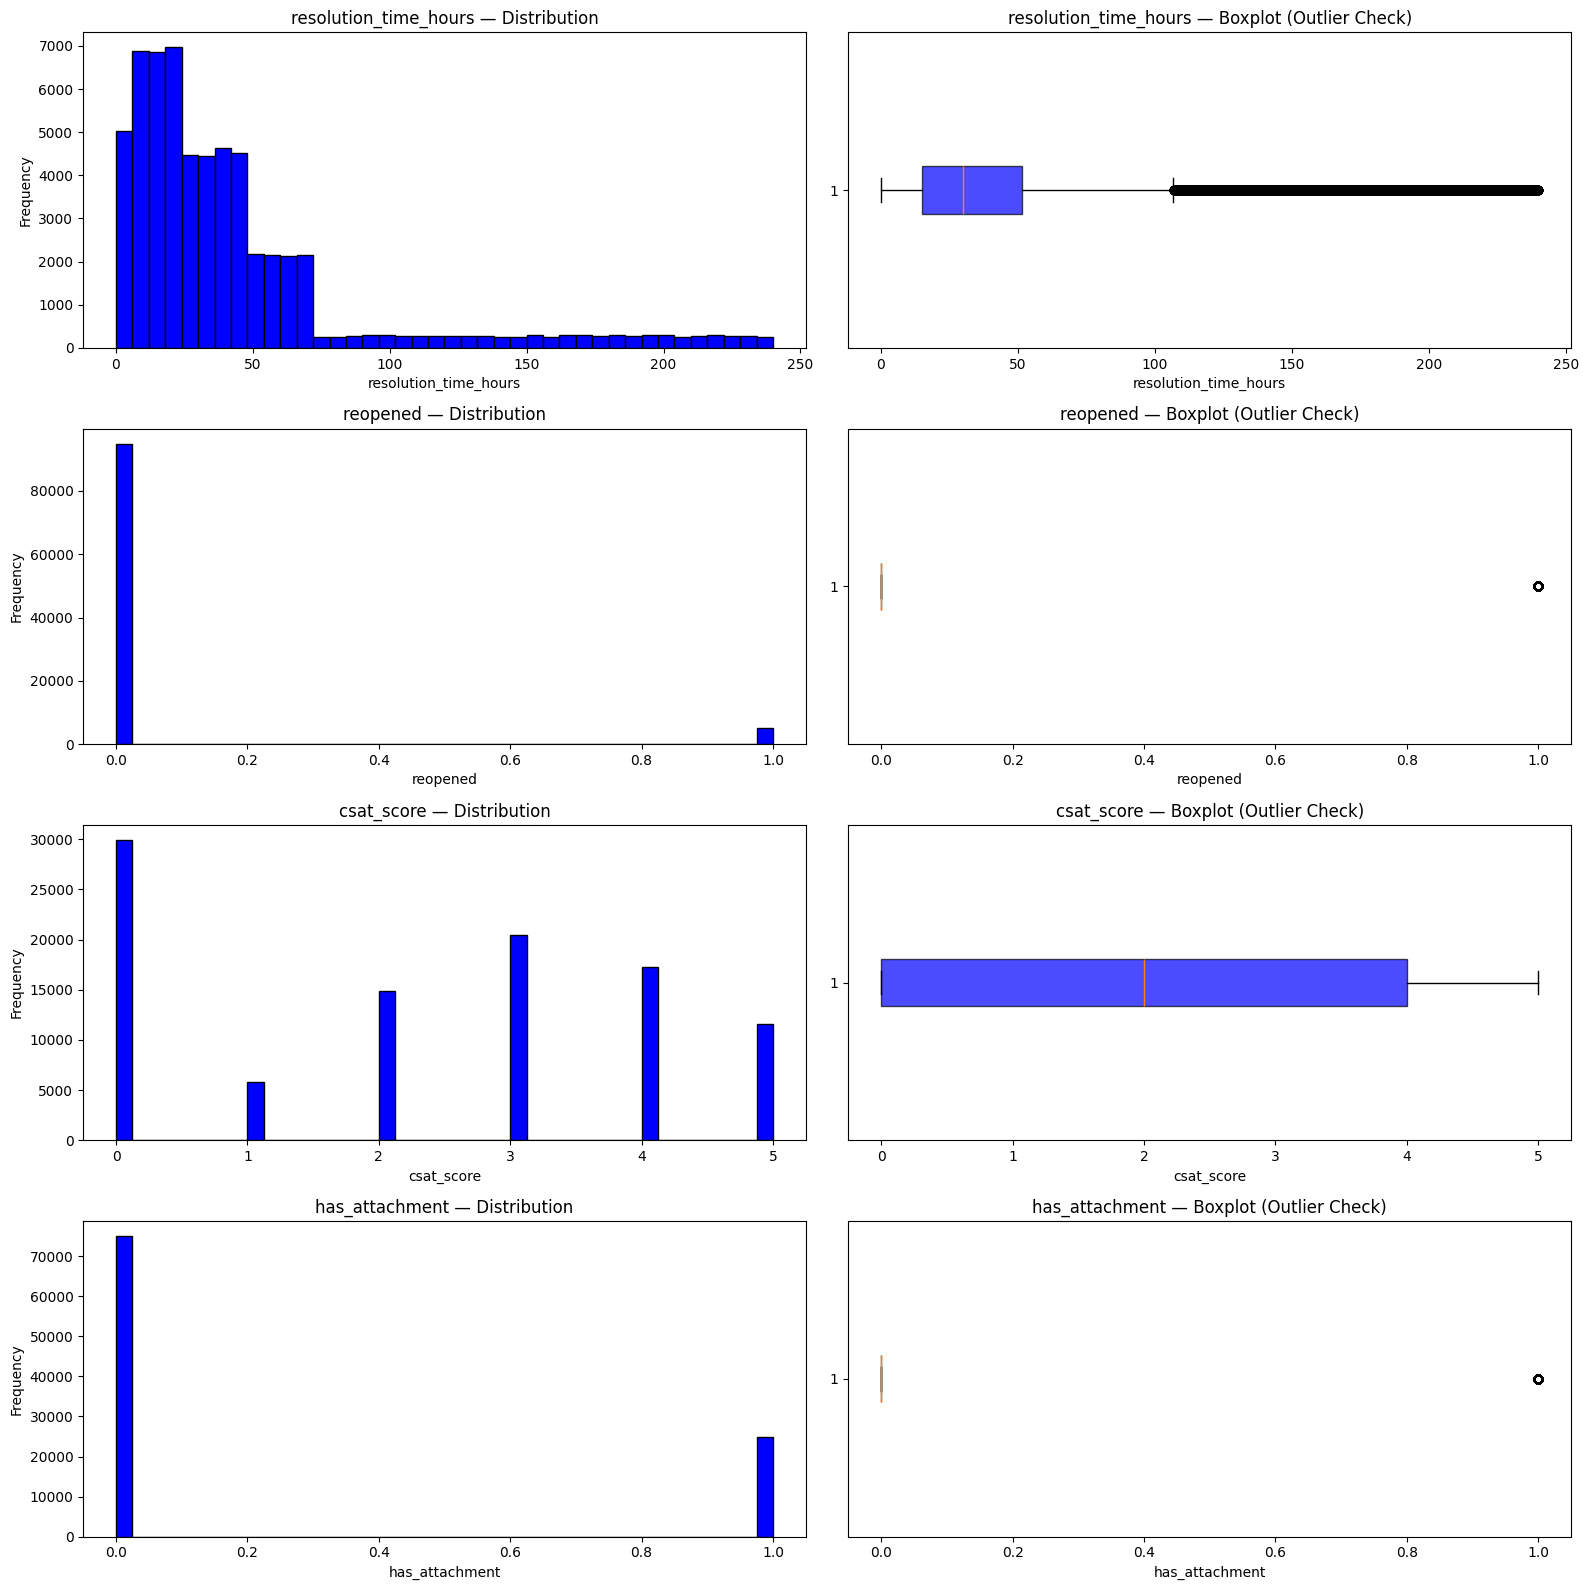

In [15]:
# Distribution plots for all numerical columns
n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(16, n * 4))

for i, col in enumerate(num_cols):
    # Histogram
    axes[i, 0].hist(
        df[col].dropna(),
        bins=40,
        color='blue',
        edgecolor='black'
    )
    axes[i, 0].set_title(f'{col} — Distribution', fontsize=12)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    # Boxplot (detects outliers)
    axes[i, 1].boxplot(
        df[col].dropna(),
        vert=False,
        patch_artist=True,
        boxprops=dict(facecolor='blue', alpha=0.7)
    )
    axes[i, 1].set_title(f'{col} — Boxplot (Outlier Check)', fontsize=12)
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

In [16]:
df[num_cols].skew()

resolution_time_hours    2.181345
reopened                 4.107949
csat_score              -0.004273
has_attachment           1.157677
dtype: float64

###  Categorical Feature Analysis

In [17]:
print("UNIQUE VALUE COUNTS PER CATEGORICAL COLUMN")
print("=" * 50)
for col in cat_cols:
    print(f"{col:40} → {df[col].nunique()} unique values")

UNIQUE VALUE COUNTS PER CATEGORICAL COLUMN
ticket_id                                → 100000 unique values
created_at                               → 99959 unique values
customer_id                              → 9999 unique values
customer_segment                         → 5 unique values
channel                                  → 5 unique values
product_area                             → 7 unique values
issue_type                               → 8 unique values
priority                                 → 4 unique values
sla_plan                                 → 3 unique values
initial_message                          → 96 unique values
agent_first_reply                        → 32 unique values
resolution_summary                       → 9 unique values
platform                                 → 5 unique values
region                                   → 4 unique values


In [18]:
print("VALUE COUNTS FOR CATEGORICAL COLUMNS WITH < 200 UNIQUE VALUES")
print("=" * 60)

for col in cat_cols:
    if df[col].nunique() < 200:
        print(f"\nColumn: {col}")
        print("-" * 40)
        print(df[col].value_counts(normalize=True)*100)

VALUE COUNTS FOR CATEGORICAL COLUMNS WITH < 200 UNIQUE VALUES

Column: customer_segment
----------------------------------------
customer_segment
small_business    20.203
individual        20.033
enterprise        20.030
education         19.958
non_profit        19.776
Name: proportion, dtype: float64

Column: channel
----------------------------------------
channel
phone_transcript    20.133
email               20.088
in_app              19.982
web_form            19.965
chat                19.832
Name: proportion, dtype: float64

Column: product_area
----------------------------------------
product_area
mobile_app             14.432
login_auth             14.381
api_integration        14.350
billing                14.289
data_export            14.262
analytics_dashboard    14.187
notifications          14.099
Name: proportion, dtype: float64

Column: issue_type
----------------------------------------
issue_type
how_to              12.739
account_access      12.609
performance      

In [19]:
print(df.groupby('platform')['escalated'].mean())
print(df.groupby('region')['escalated'].mean())


platform
android        0.585616
api_client     0.577955
desktop_app    0.575269
ios            0.578140
web            0.569538
Name: escalated, dtype: float64
region
APAC     0.582000
EU       0.573998
LATAM    0.577634
MEA      0.580269
Name: escalated, dtype: float64


##  Correlation Analysis

In [20]:
df.duplicated().sum()

0

In [21]:
corr = df[num_cols].corr()

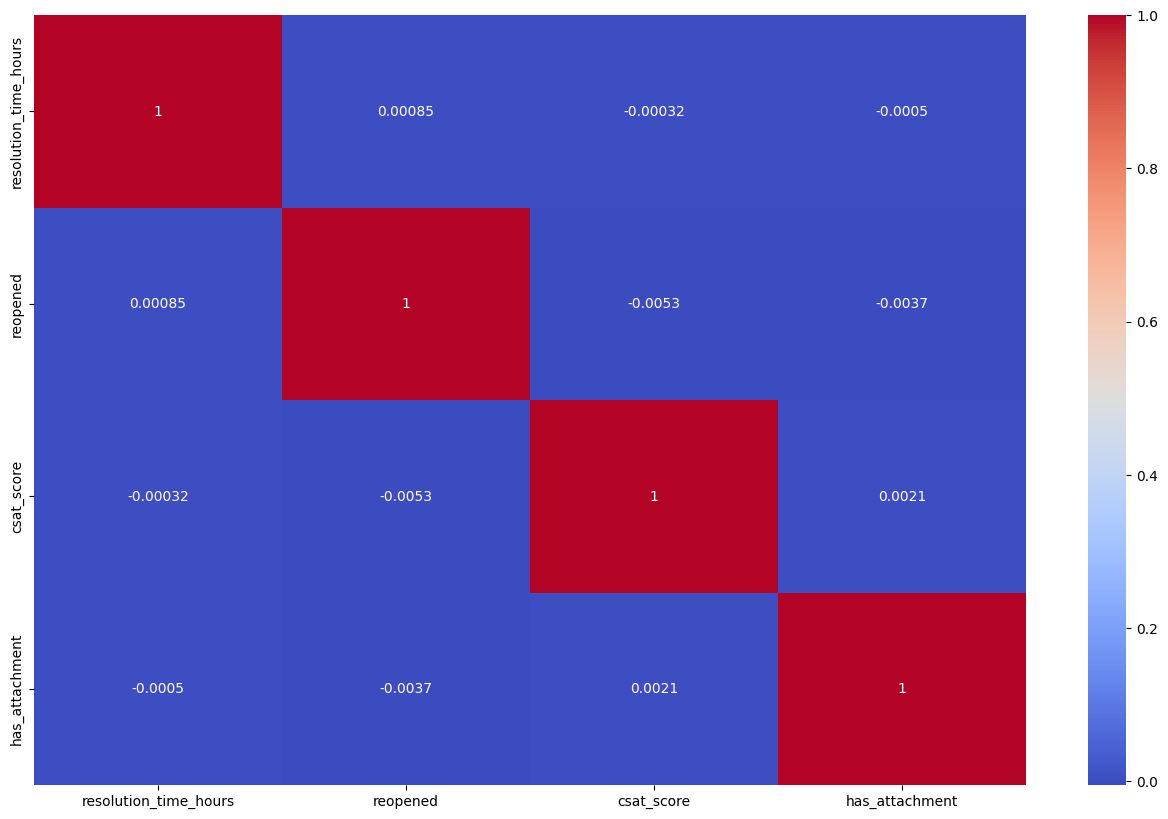

In [22]:
plt.figure(figsize=(16,10))
sns.heatmap(corr,cmap='coolwarm',annot=True)
plt.show();

In [23]:
corr_with_target = (df[num_cols+['escalated']].corr()['escalated'])
print(corr_with_target)

resolution_time_hours    0.281142
reopened                 0.197240
csat_score              -0.762186
has_attachment          -0.004703
escalated                1.000000
Name: escalated, dtype: float64


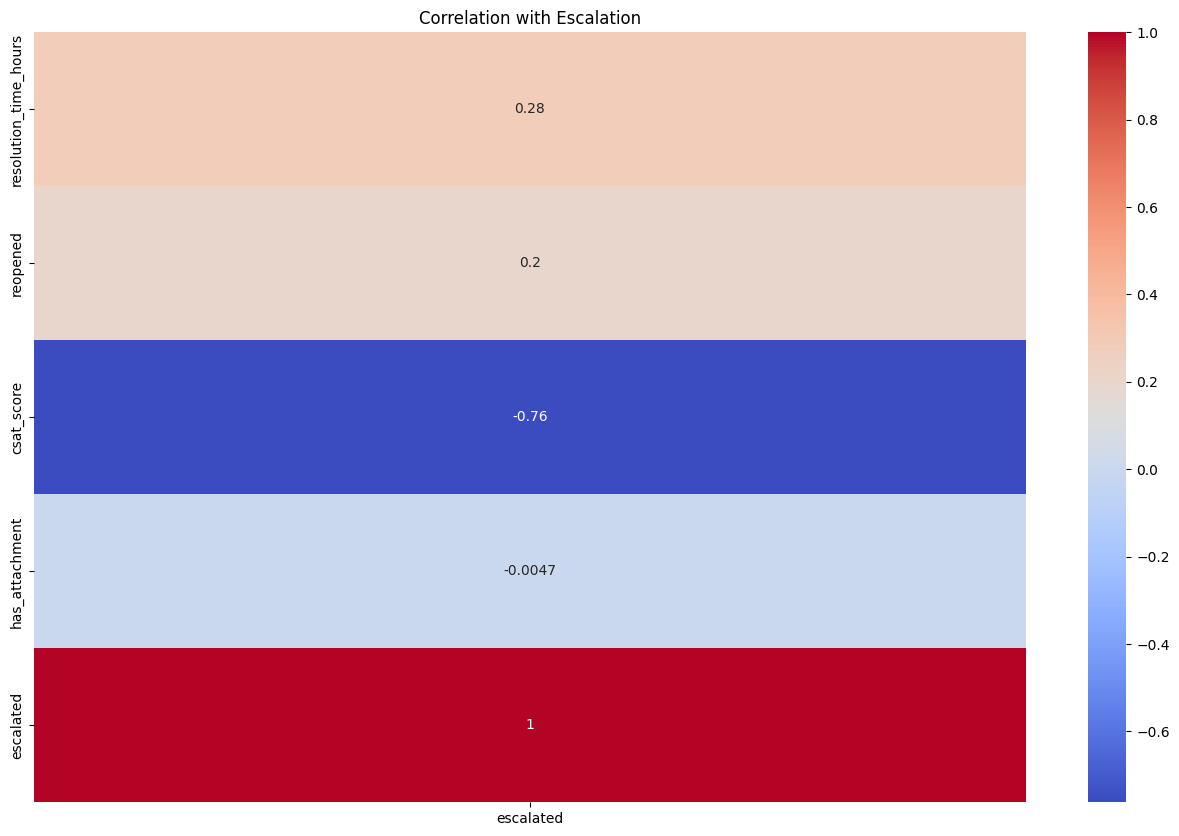

In [24]:
plt.figure(figsize=(16,10))

sns.heatmap(
    corr_with_target.to_frame(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation with Escalation')
plt.show()